### Simulacion de Procesos Financieros
**Andre Esteban Vera - 745232**
19/08/2026

## Clase 4 - Calcular volatilidad mediante datos historicos

### Ejercicio de Introduccion

supon que tienes 10 dados juntos, cual es la probabilidad de que, al tirarlos, la suma sea multiplo de 6?
Usar:

numpy random randint
simular 100,000 escenarios.

In [1]:
import numpy as np

np.random.seed(42)

n_dados = 10
M = 100_000

tiros = np.random.randint(1, 7, size=(M, n_dados))   # matriz M x 10
sumas = tiros.sum(axis=1)                            # suma de cada escenario
exito = (sumas % 6 == 0)                             # multiplo de 6

prob = exito.mean()

print(f"Escenarios favorables : {exito.sum():,} de {M:,}")
print(f"Probabilidad simulada : {prob:.5f}  ({prob*100:.3f}%)")
print(f"Probabilidad teórica  : {1/6:.5f}  ({100/6:.3f}%)")

Escenarios favorables : 16,784 de 100,000
Probabilidad simulada : 0.16784  (16.784%)
Probabilidad teórica  : 0.16667  (16.667%)


In [2]:
# Importar dataset
import pandas as pd
data = pd.read_csv('aapl_historical_data_2026_h1.csv')
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2026-01-01,271.13,273.16,270.33,271.76,271.76,48088862
1,2026-01-02,271.56,272.35,270.12,271.01,271.01,52964103
2,2026-01-05,267.08,268.92,265.37,267.40,267.40,63173862
3,2026-01-06,267.77,267.94,265.54,267.45,267.45,55112033
4,2026-01-07,267.95,268.14,265.63,267.63,267.63,67043445


In [3]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,129.000000,129.000000,129.000000,129.000000,129.000000,1.290000e+02
mean,273.857752,275.399845,272.113023,273.789225,273.789225,5.966355e+07
std,20.204258,20.277666,20.036950,20.061188,20.061188,1.431972e+07
min,246.640000,248.020000,245.090000,246.610000,246.610000,3.506766e+07
25%,258.870000,259.570000,256.720000,258.610000,258.610000,4.808886e+07
50%,267.950000,269.110000,266.340000,268.080000,268.080000,5.824098e+07
75%,290.660000,293.030000,288.590000,291.410000,291.410000,7.108139e+07
max,315.670000,318.000000,313.090000,315.200000,315.200000,8.409440e+07


In [6]:
# Encontrar el dia en el que hubo menos y mas operaciones
min_operations = data['Volume'].min()
max_operations = data['Volume'].max()
print(f"El día con menos operaciones tuvo {min_operations} operaciones.")
print(f"El día con más operaciones tuvo {max_operations} operaciones.")

# Y la fecha en la que ocurrieron
min_operations_date = data.loc[data['Volume'] == min_operations, 'Date'].values[0]
max_operations_date = data.loc[data['Volume'] == max_operations, 'Date'].values[0]
print(f"El día con menos operaciones fue: {min_operations_date}")
print(f"El día con más operaciones fue: {max_operations_date}")


El día con menos operaciones tuvo 35067661 operaciones.
El día con más operaciones tuvo 84094405 operaciones.
El día con menos operaciones fue: 2026-06-17
El día con más operaciones fue: 2026-03-09


In [7]:
# Agregamos al dataset una columna con el logaritmo de los precios de cierre, usando: rendimiento (u) = ln(S_t / S_(t-1)) 
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Log_Return
0,2026-01-01,271.13,273.16,270.33,271.76,271.76,48088862,NaN
1,2026-01-02,271.56,272.35,270.12,271.01,271.01,52964103,-0.002764
2,2026-01-05,267.08,268.92,265.37,267.40,267.40,63173862,-0.013410
3,2026-01-06,267.77,267.94,265.54,267.45,267.45,55112033,0.000187
4,2026-01-07,267.95,268.14,265.63,267.63,267.63,67043445,0.000673


In [9]:
# contamos cantidad de datos de log_return
log_return_count = data['Log_Return'].count()
log_return_count

np.int64(128)

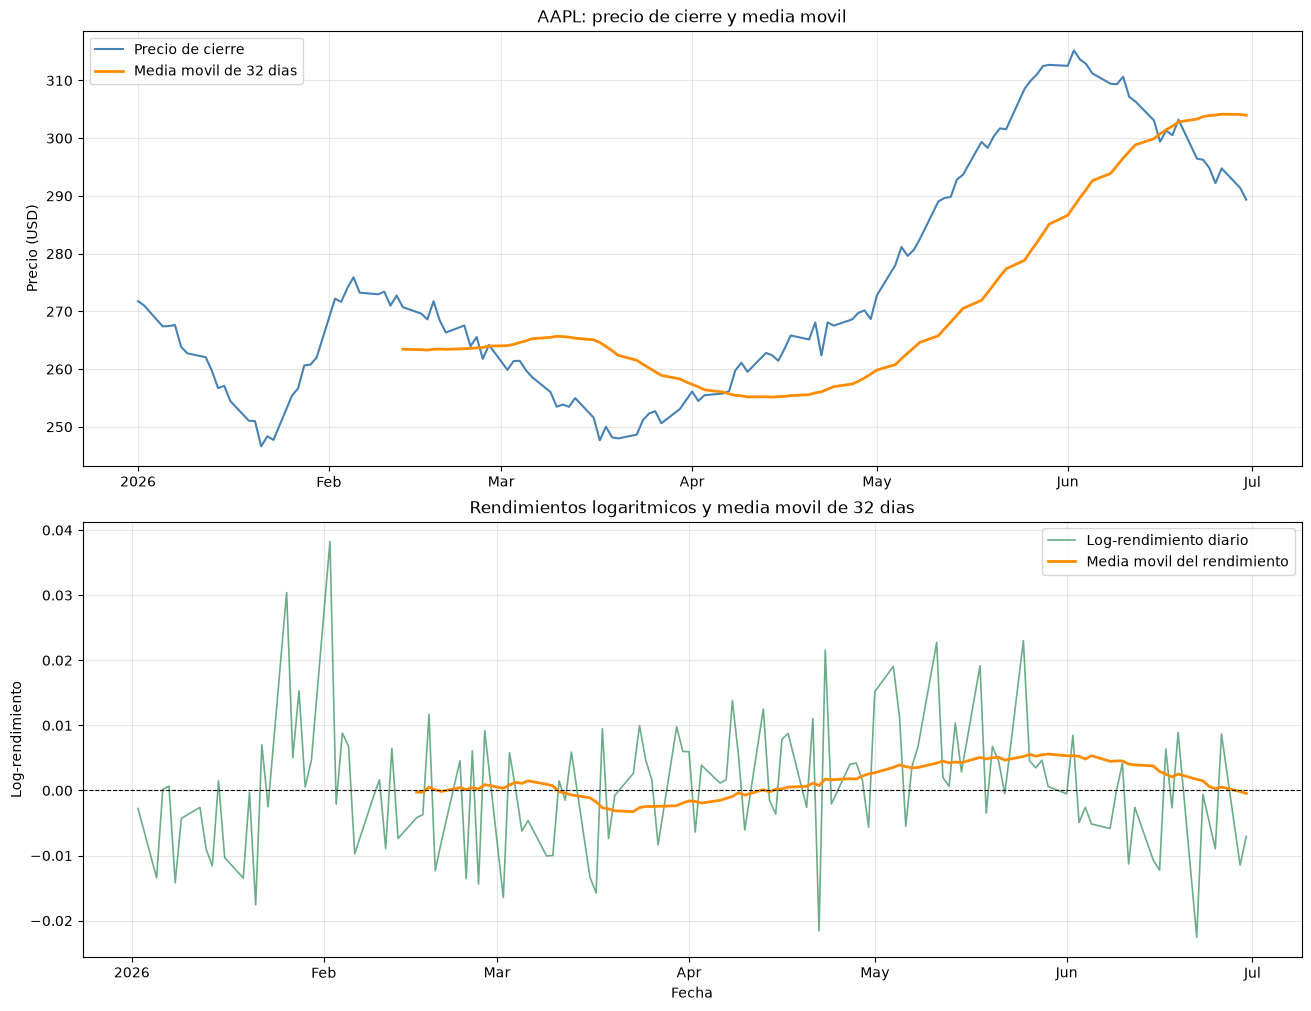

In [19]:
# Media movil de 32 dias: cada punto usa los 32 datos mas recientes
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convertimos la columna Date para graficarla como una serie temporal
data['Date'] = pd.to_datetime(data['Date'])
periodo = 32

# Media movil simple del precio de cierre.
data['MA_32'] = data['Close'].rolling(window=periodo, min_periods=periodo).mean()

# Media movil de los rendimientos logaritmicos.
data['Mean_Return_32'] = data['Log_Return'].rolling(
    window=periodo,
    min_periods=periodo
).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 10), constrained_layout=True)

# Precio de cierre y media movil de 32 dias.
axes[0].plot(data['Date'], data['Close'], color='steelblue', label='Precio de cierre')
axes[0].plot(data['Date'], data['MA_32'], color='darkorange', linewidth=2,
             label='Media movil de 32 dias')
axes[0].set_title('AAPL: precio de cierre y media movil')
axes[0].set_ylabel('Precio (USD)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Rendimientos logaritmicos y su media movil de 32 dias.
axes[1].plot(data['Date'], data['Log_Return'], color='seagreen', linewidth=1.2,
             alpha=0.7, label='Log-rendimiento diario')
axes[1].plot(data['Date'], data['Mean_Return_32'], color='darkorange', linewidth=2,
             label='Media movil del rendimiento')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Rendimientos logaritmicos y media movil de 32 dias')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Log-rendimiento')
axes[1].legend()
axes[1].grid(alpha=0.3)

for axis in axes:
    locator = mdates.AutoDateLocator()
    axis.xaxis.set_major_locator(locator)
    axis.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

plt.show()

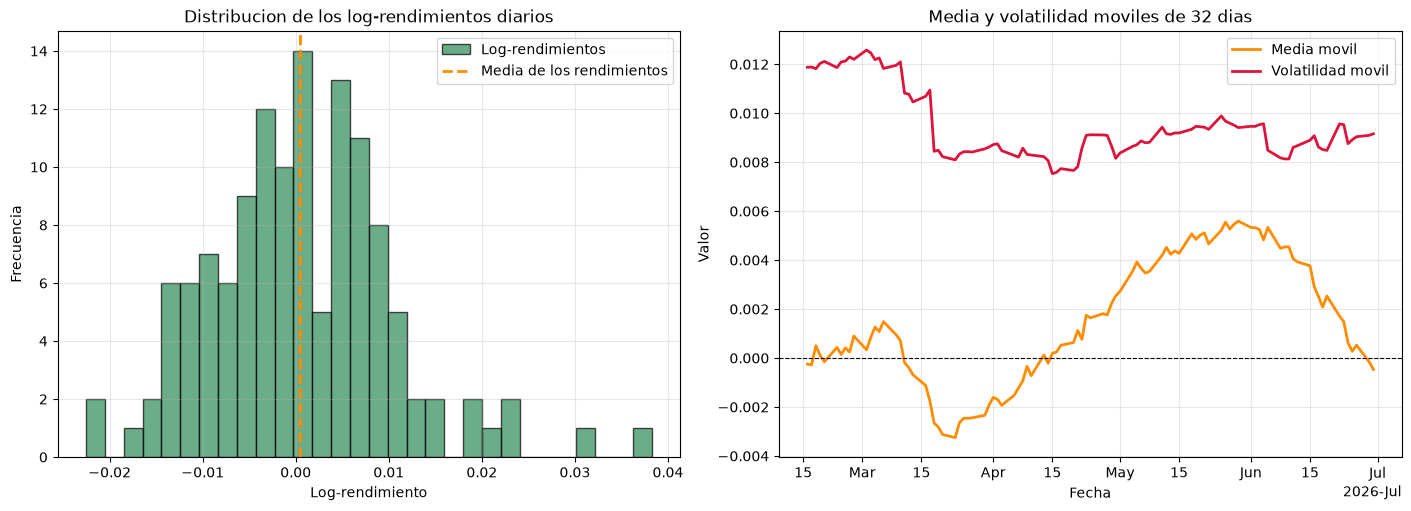

In [20]:
# Distribucion de los log-rendimientos y estadisticas moviles de 32 dias
media_movil_rendimientos = data['Log_Return'].rolling(
    window=periodo,
    min_periods=periodo
).mean()
volatilidad_movil_rendimientos = data['Log_Return'].rolling(
    window=periodo,
    min_periods=periodo
).std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Histograma de la distribucion de los log-rendimientos.
axes[0].hist(data['Log_Return'].dropna(), bins=30, color='seagreen',
             edgecolor='black', alpha=0.7, label='Log-rendimientos')
axes[0].axvline(data['Log_Return'].mean(), color='darkorange', linewidth=2,
                linestyle='--', label='Media de los rendimientos')
axes[0].set_title('Distribucion de los log-rendimientos diarios')
axes[0].set_xlabel('Log-rendimiento')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Evolucion de la media y volatilidad moviles.
axes[1].plot(data['Date'], media_movil_rendimientos, color='darkorange',
             linewidth=2, label='Media movil')
axes[1].plot(data['Date'], volatilidad_movil_rendimientos, color='crimson',
             linewidth=2, label='Volatilidad movil')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Media y volatilidad moviles de 32 dias')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Valor')
axes[1].legend()
axes[1].grid(alpha=0.3)

locator = mdates.AutoDateLocator()
axes[1].xaxis.set_major_locator(locator)
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

plt.show()

### Media y Volatilidad Muestral Movil

Calcularemos la media y la volatilidad muestral de los log-rendimientos utilizando una ventana movil de 32 dias. 

Para cada ventana calcularemos la media diaria, la volatilidad diaria y la volatilidad anualizada.

In [21]:
# Media y volatilidad muestral movil de los log-rendimientos
rendimientos = data['Log_Return']

# Cada fila usa los 32 rendimientos mas recientes.
media_movil = rendimientos.rolling(
    window=periodo,
    min_periods=periodo
).mean()
volatilidad_movil = rendimientos.rolling(
    window=periodo,
    min_periods=periodo
).std()

# Tabla con una fila por cada ventana movil completa.
estadisticas = pd.DataFrame({
    'Fecha': data['Date'],
    'Media': media_movil,
    'Volatilidad diaria': volatilidad_movil,
    'Volatilidad anualizada': volatilidad_movil * np.sqrt(252)
}).dropna().reset_index(drop=True)

estadisticas[['Media', 'Volatilidad diaria', 'Volatilidad anualizada']] = (
    estadisticas[['Media', 'Volatilidad diaria', 'Volatilidad anualizada']].round(6)
)
estadisticas

,Fecha,Media,Volatilidad diaria,Volatilidad anualizada
0,2026-02-16,-0.000248,0.011877,0.188540
1,2026-02-17,-0.000278,0.011885,0.188662
2,2026-02-18,0.000505,0.011817,0.187590
3,2026-02-19,0.000114,0.012033,0.191020
4,2026-02-20,-0.000152,0.012114,0.192311
...,...,...,...,...
92,2026-06-24,0.000620,0.008758,0.139026
93,2026-06-25,0.000277,0.008915,0.141521
94,2026-06-26,0.000529,0.009038,0.143477
95,2026-06-29,-0.000153,0.009095,0.144386


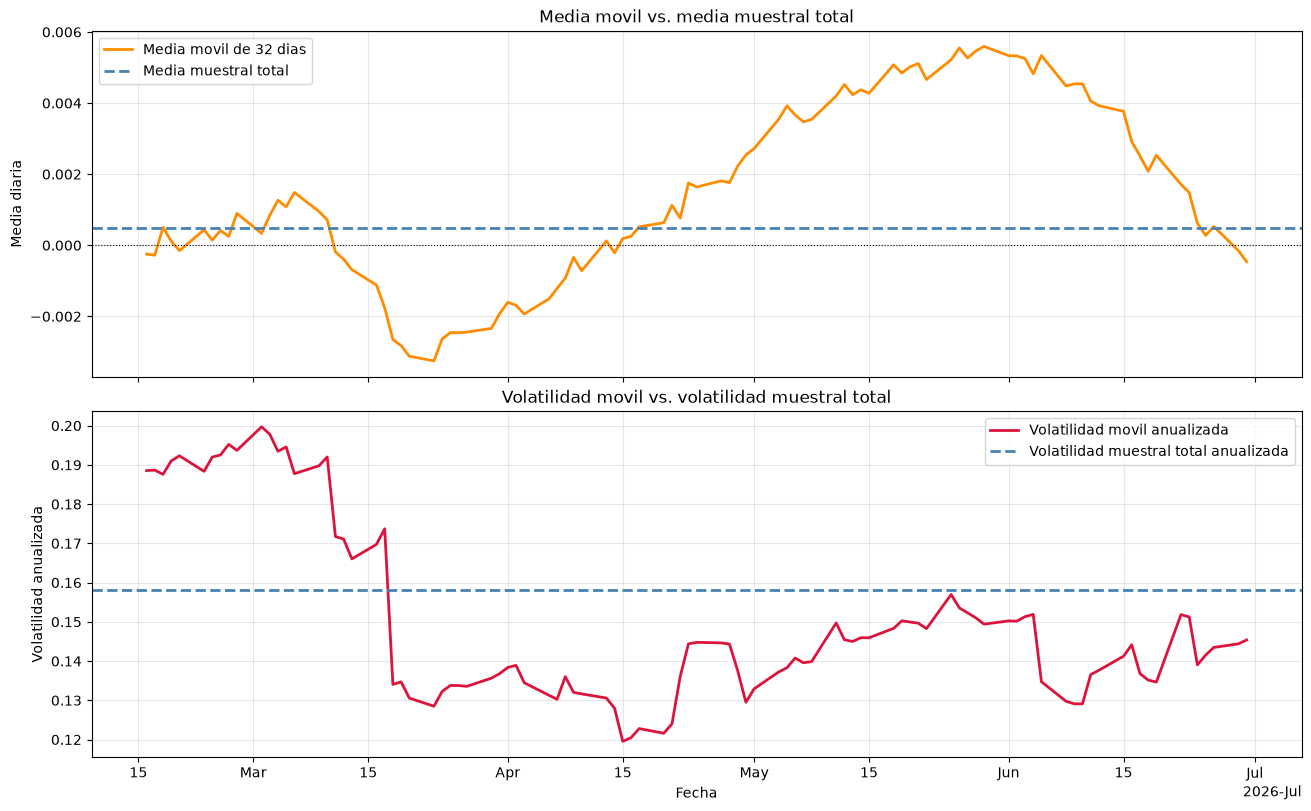

Media muestral total: 0.000490
Volatilidad diaria muestral total: 0.009958
Volatilidad anualizada muestral total: 0.158084


In [23]:
# Comparamos las estadisticas moviles con las del conjunto completo
rendimientos_validos = data['Log_Return'].dropna()
cantidad_total = len(rendimientos_validos)

# Media y desviacion estandar muestrales de todos los log-rendimientos.
media_total = rendimientos_validos.sum() / cantidad_total
volatilidad_total = np.sqrt(
    ((rendimientos_validos - media_total) ** 2).sum() / (cantidad_total - 1)
)
volatilidad_total_anualizada = volatilidad_total * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, constrained_layout=True)

# Media movil contra la media muestral de todo el conjunto.
axes[0].plot(estadisticas['Fecha'], estadisticas['Media'], color='darkorange',
             linewidth=2, label='Media movil de 32 dias')
axes[0].axhline(media_total, color='steelblue', linewidth=2, linestyle='--',
                label='Media muestral total')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle=':')
axes[0].set_title('Media movil vs. media muestral total')
axes[0].set_ylabel('Media diaria')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Volatilidad movil contra la volatilidad muestral anualizada total.
axes[1].plot(estadisticas['Fecha'], estadisticas['Volatilidad anualizada'],
             color='crimson', linewidth=2, label='Volatilidad movil anualizada')
axes[1].axhline(volatilidad_total_anualizada, color='steelblue', linewidth=2,
                linestyle='--', label='Volatilidad muestral total anualizada')
axes[1].set_title('Volatilidad movil vs. volatilidad muestral total')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Volatilidad anualizada')
axes[1].legend()
axes[1].grid(alpha=0.3)

locator = mdates.AutoDateLocator()
axes[1].xaxis.set_major_locator(locator)
axes[1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

plt.show()

print(f'Media muestral total: {media_total:.6f}')
print(f'Volatilidad diaria muestral total: {volatilidad_total:.6f}')
print(f'Volatilidad anualizada muestral total: {volatilidad_total_anualizada:.6f}')